In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# === 1. Load Data from CSV ===
file_path = 'kpi_topsis_ready.csv'
df = pd.read_csv(file_path)

print(df.columns)

print(df.describe())

# === 2. Variables to Analyze ===
variables_to_analyze = [
    'RetentionRate_adj', 
    'LossRatio_adj', 
    'SubmissionQuality', 
    'EarnedPremium',
    'ExpenseRatio'
]

Index(['AgentCode', 'PeriodStart', 'PeriodEnd', 'RetentionRate_adj',
       'SubmissionQuality', 'LRadj_BENEFIT_inverted', 'EarnedPremium',
       'IncurredLoss', 'CommissionAmount', 'CommissionWrittenPremium',
       'EligibleForRenewal', 'Renewals', 'PoliciesActive', 'NewCount',
       'RewriteCount', 'Submitted', 'Quoted', 'Bound', 'RewrittenPolicyRatio',
       'LossRatio', 'RetentionRate', 'LossRatio_adj', 'ERadj_BENEFIT_inverted',
       'ExpenseRatio_raw', 'ExpenseRatio', 'EP_percentile_peer',
       'EP_decile_peer', 'EP_utility_peer'],
      dtype='object')
       RetentionRate_adj  SubmissionQuality  LRadj_BENEFIT_inverted  \
count         301.000000         301.000000              301.000000   
mean            0.795032           0.333150                0.399003   
std             0.073898           0.031815                0.098934   
min             0.582800           0.270300                0.100000   
25%             0.744700           0.310300                0.332500   
5

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")  # keep seaborn styling
plt.rcParams.update({
    "figure.facecolor": "#111111",
    "axes.facecolor":   "#111111",
    "axes.edgecolor":   "#BBBBBB",
    "axes.labelcolor":  "white",
    "text.color":       "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "grid.color":       "#444444",
    "grid.alpha":       0.4,
    "legend.facecolor": "#111111",
    "legend.edgecolor": "#999999",
    "savefig.facecolor":"#111111",
    "savefig.edgecolor":"#111111",
})



📊 Analyzing 'RetentionRate_adj':


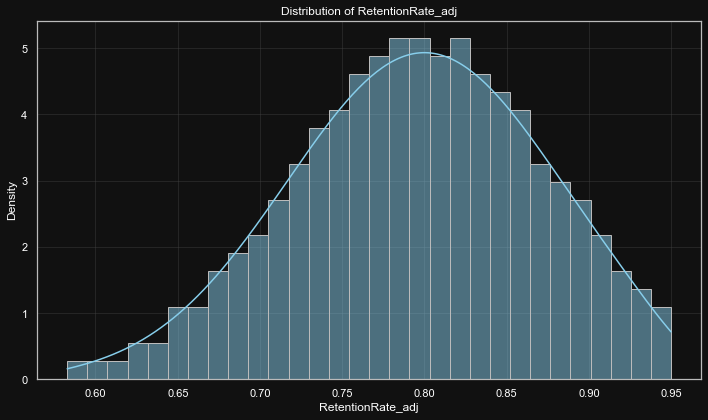

✅ Best-fitting distributions for RetentionRate_adj:
 - beta: D=0.0148, p=1.0000
 - norm: D=0.0194, p=0.9998
 - lognorm: D=0.0194, p=0.9998

📊 Analyzing 'LossRatio_adj':


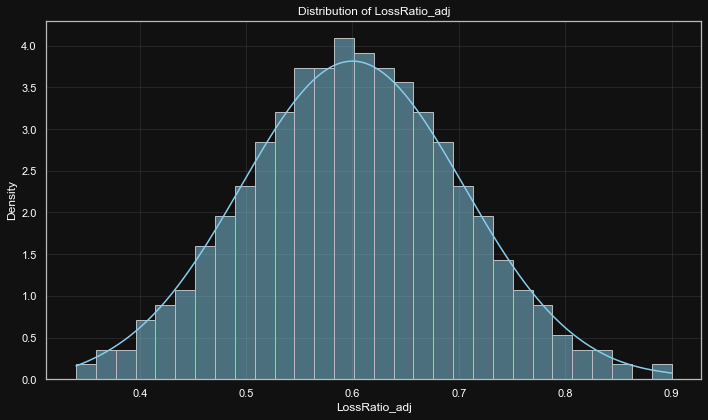

✅ Best-fitting distributions for LossRatio_adj:
 - norm: D=0.0054, p=1.0000
 - beta: D=0.0058, p=1.0000
 - gamma: D=0.0050, p=1.0000

📊 Analyzing 'SubmissionQuality':


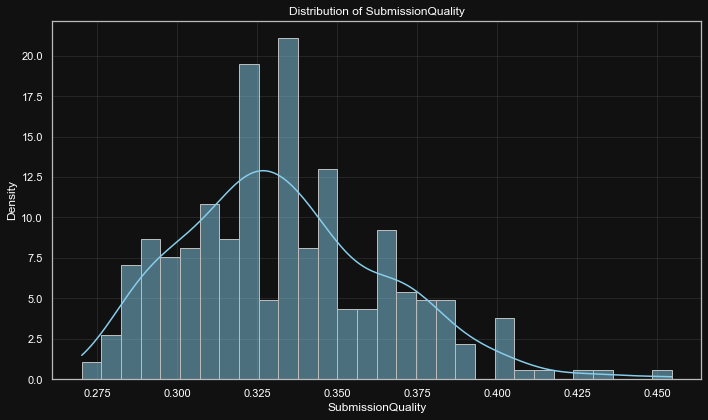

✅ Best-fitting distributions for SubmissionQuality:
 - lognorm: D=0.0649, p=0.1513
 - gamma: D=0.0662, p=0.1362
 - beta: D=0.0690, p=0.1083

📊 Analyzing 'EarnedPremium':


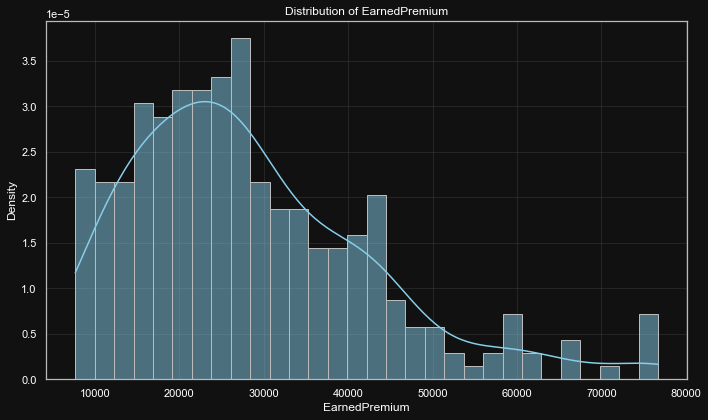

✅ Best-fitting distributions for EarnedPremium:
 - lognorm: D=0.0311, p=0.9238
 - beta: D=0.0315, p=0.9162
 - gamma: D=0.0375, p=0.7758

📊 Analyzing 'ExpenseRatio':


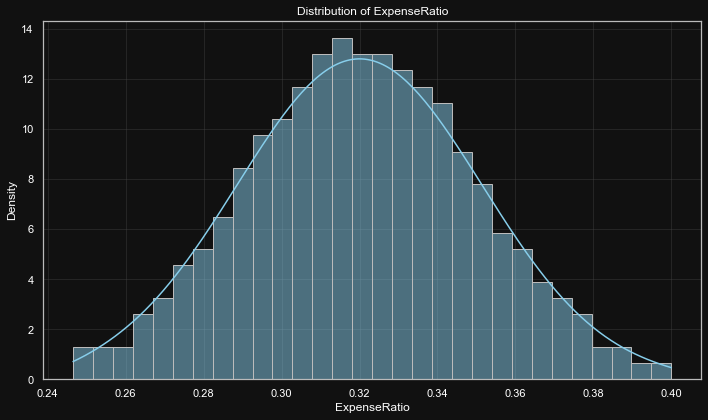

✅ Best-fitting distributions for ExpenseRatio:
 - norm: D=0.0081, p=1.0000
 - beta: D=0.0079, p=1.0000
 - gamma: D=0.0074, p=1.0000

📋 Summary of Best-Fit Distributions:
 - RetentionRate_adj: Best fit = beta, p-value = 1.0000
 - LossRatio_adj: Best fit = norm, p-value = 1.0000
 - SubmissionQuality: Best fit = lognorm, p-value = 0.1513
 - EarnedPremium: Best fit = lognorm, p-value = 0.9238
 - ExpenseRatio: Best fit = norm, p-value = 1.0000


In [42]:
# === 3. Function to Plot and Analyze Distribution ===
def analyze_distribution(data, variable_name):
    print(f"\n📊 Analyzing '{variable_name}':")
    
    series = data[variable_name].dropna()
    if series.empty:
        print("No data available for analysis.")
        return []

    # Plot histogram and KDE
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.histplot(series, kde=True, bins=30, stat='density',
                color='skyblue', edgecolor='#BBBBBB')  # lighter edges on dark bg
    plt.title(f"Distribution of {variable_name}")
    plt.xlabel(variable_name)
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Fit distributions and test
    distributions = ['norm', 'beta', 'gamma', 'lognorm', 'expon']
    results = {}

    for dist_name in distributions:
        try:
            dist = getattr(stats, dist_name)
            params = dist.fit(series)
            D, p_value = stats.kstest(series, dist_name, args=params)
            results[dist_name] = {
                'D_statistic': D,
                'p_value': p_value,
                'params': params
            }
        except Exception as e:
            print(f"❌ Failed to fit {dist_name}: {e}")

    # Sort by best p-value
    sorted_results = sorted(results.items(), key=lambda x: x[1]['p_value'], reverse=True)

    print(f"✅ Best-fitting distributions for {variable_name}:")
    for dist_name, res in sorted_results[:3]:
        print(f" - {dist_name}: D={res['D_statistic']:.4f}, p={res['p_value']:.4f}")

    return sorted_results

# === 4. Run Analysis ===
distribution_results = {}

for var in variables_to_analyze:
    if var in df.columns:
        results = analyze_distribution(df, var)
        distribution_results[var] = results
    else:
        print(f"⚠️ Column '{var}' not found in the data.")

# === 5. Summary Report ===
print("\n📋 Summary of Best-Fit Distributions:")
for var, fits in distribution_results.items():
    if fits:
        best_fit = fits[0]
        print(f" - {var}: Best fit = {best_fit[0]}, p-value = {best_fit[1]['p_value']:.4f}")